# Enterprise-Multiple -- is EV/EBITDA a real value edge?
### The practitioner's favourite cheapness ratio, sorted honestly on the S&P 500 large caps

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cheap_beats_expensive%3F: Mixed](https://img.shields.io/badge/Cheap_beats_expensive%3F-Mixed-8b949e?style=flat-square)

Every banker and value investor quotes **EV/EBITDA** -- enterprise value over operating earnings. A *low* multiple means the whole firm (equity **plus** net debt) is cheap relative to the cash its operations throw off. Loughran & Wellman (2011) showed it predicts returns: buy the low-multiple names, sell the high-multiple ones. This notebook tests that idea on a large-cap survivor basket, honestly.

> Plain-language layer. For HAC *t*-stats, the placebo null and the positive control see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from enterprise_multiple import data, strategy as st

_study_cache = os.path.abspath(os.path.join("..", "_cache"))

def _have_real():
    return (os.path.exists(os.path.join(_study_cache, "em_panel.parquet"))
            and os.path.exists(os.path.join(_study_cache, "fwd_ret.parquet")))

HAVE_REAL = _have_real()
if HAVE_REAL:
    em, fwd = data.fetch_panel(cache_dir=_study_cache)
else:
    em, fwd = pd.DataFrame(), pd.DataFrame()

print("real data available:", HAVE_REAL, f"  panel: {em.shape if not em.empty else 'n/a'}")


real data available: True   panel: (39, 35)


## The answer first

| Question | Answer |
|---|---|
| Does a low EV/EBITDA predict returns? | **Not significantly.** Hedge **+8.8%/yr**, HAC *t* = **+1.11**. |
| Does it beat a coin (placebo)? | **No.** A within-month label shuffle puts it at **p = 0.30**. |
| Do cheap names beat expensive ones at all? | **As a ranking, yes.** Cheap leg Sharpe **1.19** vs expensive **0.53**. |
| Could you trade the spread? | **No.** Net **+8.2%/yr**, *t* +1.04 -- still indistinguishable from zero. |

> The ratio sorts the right way, but the long-short trade that would monetise it can't clear the statistical bar on this large-cap survivor sample -- exactly where the factor-decay literature (and Loughran-Wellman themselves) say a large-cap-only test should land.

## 1 · The claim

> *'Forget P/E -- it ignores debt and gets distorted by depreciation games. Use **EV/EBITDA**: enterprise value (market cap + total debt - cash) over operating earnings before D&A. Buy the cheapest decile, sell the dearest, hold, rebalance. It is the cleanest value yardstick because it is capital-structure-neutral.'*

The supporting evidence is **Loughran & Wellman (2011)**, who found EV/EBITDA a robust cross-sectional predictor in the US -- though, crucially, **concentrated in smaller, less-liquid names**. Our test deliberately uses large, liquid survivors, the hardest place for any value premium to survive.

## 2 · So what?

If the multiple still pays in large caps, it is a simple, low-turnover, once-a-year-signal strategy any retail investor could run. If it has been arbed away -- the obvious fate of a metric every analyst on Wall Street stares at daily -- then the accounting logic is fine but the trading conclusion does not follow. The interesting twist is that EV/EBITDA might still *rank* correctly (cheap beats dear) without the *spread* being tradable.

## 3 · How would we even know?

The protocol:

1. **No look-ahead.** Each fiscal year's multiple is treated as public only after a 4-month reporting lag, then held for 12 months; the position is entered the *next* month.
2. **A fair baseline.** The dollar-neutral long-short hedge (cheap minus expensive) is compared to zero, not to a leveraged benchmark.
3. **A placebo.** Shuffle the multiple across names *within each month* and re-run; the real result must beat that null.
4. **Survivorship caveat.** The basket is names still trading in 2026 -- the expensive names that later imploded and delisted are absent. This should *flatter* the trade; finding nothing here is conservative.

Data: yfinance annual EBITDA, total debt, cash and shares; monthly adjusted prices; **35 large-cap names, 2023-03 .. 2026-05 (38 months).** (5 banks drop out -- EBITDA is meaningless for financials.)

## 4 · The teardown -- let's actually look

**First: the cheap leg vs the expensive leg vs the market.**

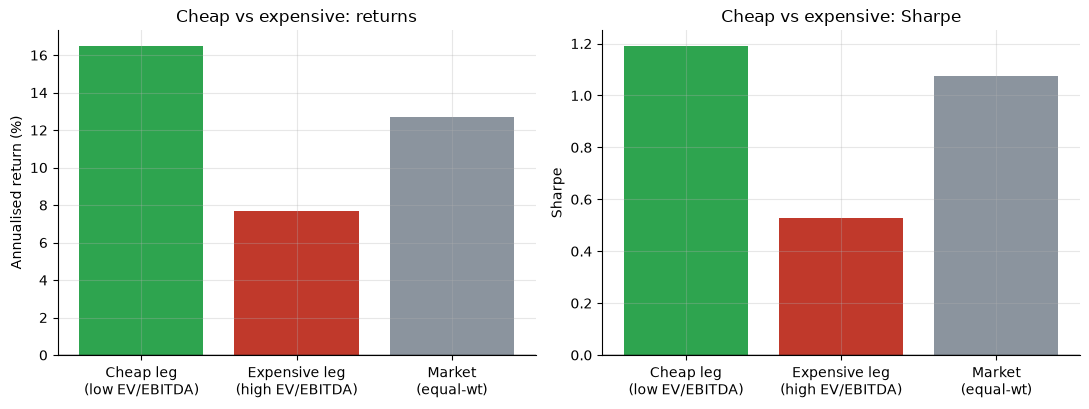

Cheap Sharpe +1.19  vs  Expensive Sharpe +0.53  (market +1.08)


In [2]:
long_mean, short_mean, mkt_mean = 0.165, 0.077, 0.127
long_sh, short_sh, mkt_sh = 1.19, 0.53, 1.08
if HAVE_REAL:
    h = st.long_short_hedge(em, fwd)
    sl, ss, sm = st.summary(h['long']), st.summary(h['short']), st.summary(h['market'])
    long_mean, short_mean, mkt_mean = sl['mean'], ss['mean'], sm['mean']
    long_sh, short_sh, mkt_sh = sl['sharpe'], ss['sharpe'], sm['sharpe']
labels = ['Cheap leg\n(low EV/EBITDA)', 'Expensive leg\n(high EV/EBITDA)', 'Market\n(equal-wt)']
means = [long_mean*100, short_mean*100, mkt_mean*100]
sharpes = [long_sh, short_sh, mkt_sh]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.bar(labels, means, color=[GREEN, RED, GREY]); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('Annualised return (%)'); a1.set_title('Cheap vs expensive: returns')
a2.bar(labels, sharpes, color=[GREEN, RED, GREY]); a2.axhline(0, c='k', lw=1)
a2.set_ylabel('Sharpe'); a2.set_title('Cheap vs expensive: Sharpe')
plt.tight_layout(); plt.show()
print(f'Cheap Sharpe {long_sh:+.2f}  vs  Expensive Sharpe {short_sh:+.2f}  '
      f'(market {mkt_sh:+.2f})')

The cheap leg (Sharpe **1.19**) genuinely out-rides the expensive leg (**0.53**) and even the market (**1.08**). So the *ranking* works. The question is whether the **difference** -- the long-short hedge -- is big enough to trade.

**Now the hedge itself, year by year.**

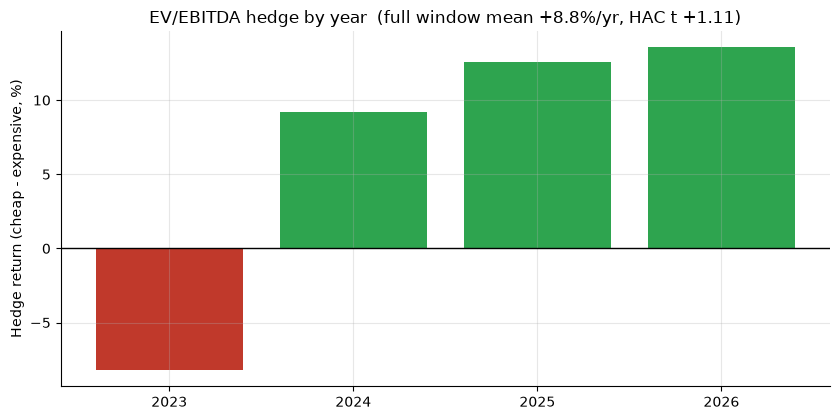

Hedge years: {2023: '-8.2%', 2024: '+9.2%', 2025: '+12.6%', 2026: '+13.5%'}


In [3]:
yr_vals = {2023: -0.082, 2024: 0.092, 2025: 0.126, 2026: 0.135}
if HAVE_REAL:
    h = st.long_short_hedge(em, fwd)
    hh = h.copy(); hh.index = hh.index.to_timestamp()
    yr_series = hh['hedge'].groupby(hh.index.year).apply(lambda x: (1+x).prod()-1)
    yr_vals = yr_series.to_dict()
yrs = list(yr_vals.keys()); vals = [yr_vals[y]*100 for y in yrs]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([str(y) for y in yrs], vals, color=[GREEN if v > 0 else RED for v in vals])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Hedge return (cheap - expensive, %)')
ax.set_title('EV/EBITDA hedge by year  (full window mean +8.8%/yr, HAC t +1.11)')
plt.tight_layout(); plt.show()
print('Hedge years:', {y: f'{v:+.1f}%' for y, v in zip(yrs, vals)})

The hedge is **+8.8%/yr** on average but lumpy: a negative 2023, then three positive years. The positive tilt is concentrated in 2025-26 (the half-split confirms it: first-half *t* = -0.07, second-half *t* = +1.39) -- not the steady premium a tradable factor needs.

## 5 · The verdict

- **Signal -- None.** Hedge +8.8%/yr, HAC *t* = **+1.11**; placebo **p = 0.30**. Below the \|*t*\| >= 2 bar and inside the shuffle null.
- **Tradability -- Mirage.** Net +8.2%/yr (*t* +1.04); costs are tiny (4.8 bps/month) but there is no gross edge to protect.
- **Cheap beats expensive? -- Mixed.** The cheap leg out-Sharpes the expensive leg (1.19 vs 0.53) -- the ranking holds -- but the spread can't be told from zero.

## 6 · Could you actually trade it?

- **The signal is stale by construction.** Fundamentals arrive months after fiscal-year end; the multiple you sort on is already old.
- **Everyone watches it.** EV/EBITDA is on every analyst's screen -- any persistent large-cap edge has been visible for decades.
- **Banks don't have an EBITDA.** Financials drop out of the sort entirely, so the 'universe' is narrower than it looks.

Costs are not the problem here -- there is simply no gross edge to erode.

## 7 · Going further

- **Small caps.** Loughran-Wellman found the premium strongest in *smaller, less-liquid* names -- the opposite of this basket. That is the natural place to look next.
- **[Study 530 -- Book-to-Market](../530-book-to-market-value/)** and **[Study 124 -- Cash-Flow-Yield](../124-cash-flow-yield/)**: the sibling value sorts. EV/EBITDA adds net debt and uses operating earnings.
- **A quality overlay.** Pairing cheap multiples with a profitability/quality screen (QMJ-style) is the standard fix when a raw value sort fails.

*Think the enterprise multiple pays somewhere? Extend to mid/small-cap with point-in-time membership and show a hedge that clears t = 2. That's the bar.*